# REINFORCE 알고리즘 기본 실습

## 학습 목표
- REINFORCE 알고리즘의 기본 원리 이해
- CartPole 환경에서 직접 구현 및 학습
- Policy Gradient의 작동 방식 체험

---

## 1단계: 필요한 라이브러리 설치 및 불러오기

적용 폰트: NanumGothic


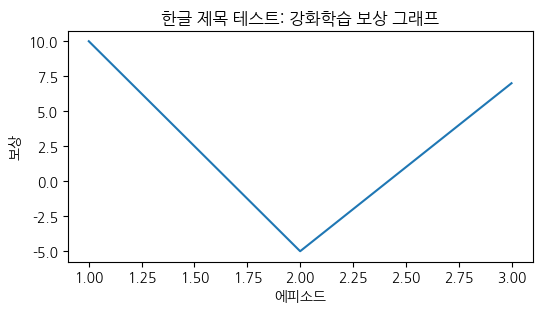

In [1]:
# 1) 한글 폰트 설치 (런타임 1회)
# !apt-get -qq update
# !apt-get -qq install -y fonts-nanum

# 2) Matplotlib에 한글 폰트 적용
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔고딕 경로 찾기
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

# 폰트 이름 가져오기(환경에 따라 정확한 이름이 다를 수 있어서 안전하게)
font_name = fm.FontProperties(fname=font_path).get_name()
print("적용 폰트:", font_name)

# 전역 설정
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False  # ✅ 마이너스(-) 깨짐 방지

# 3) 테스트
plt.figure(figsize=(6,3))
plt.plot([1,2,3], [10,-5,7])
plt.title("한글 제목 테스트: 강화학습 보상 그래프")
plt.xlabel("에피소드")
plt.ylabel("보상")
plt.show()

In [ ]:
# 필요한 라이브러리 설치
# !pip install gymnasium torch matplotlib numpy -q

**설명**: Google Colab에서 필요한 패키지들을 설치합니다.
- `gymnasium`: 강화학습 환경 (OpenAI Gym의 최신 버전)
- `torch`: 신경망 구현을 위한 PyTorch
- `matplotlib`: 그래프 시각화
- `numpy`: 수치 계산

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

print("라이브러리 불러오기 완료!")
print(f"PyTorch 버전: {torch.__version__}")

라이브러리 불러오기 완료!
PyTorch 버전: 2.10.0+cu130


---

## 2단계: CartPole 환경 살펴보기

CartPole은 막대를 균형잡는 게임입니다.
- 목표: 막대가 쓰러지지 않게 카트를 좌우로 움직이기
- 성공: 500 스텝 동안 막대 유지

In [3]:
# 환경 생성
env = gym.make('CartPole-v1')

# 환경 정보 확인
print("=== CartPole 환경 정보 ===")
print(f"상태 공간 크기: {env.observation_space.shape[0]}")
print(f"행동 개수: {env.action_space.n}")
print("\n상태 의미:")
print("  [0] 카트 위치")
print("  [1] 카트 속도")
print("  [2] 막대 각도")
print("  [3] 막대 각속도")
print("\n행동 의미:")
print("  0: 왼쪽으로 밀기")
print("  1: 오른쪽으로 밀기")

=== CartPole 환경 정보 ===
상태 공간 크기: 4
행동 개수: 2

상태 의미:
  [0] 카트 위치
  [1] 카트 속도
  [2] 막대 각도
  [3] 막대 각속도

행동 의미:
  0: 왼쪽으로 밀기
  1: 오른쪽으로 밀기


**설명**: CartPole 환경의 기본 정보를 확인합니다.
- **상태 공간**: 4차원 (카트 위치, 속도, 막대 각도, 각속도)
- **행동 공간**: 2가지 (왼쪽, 오른쪽)

In [4]:
# 랜덤 정책으로 한 에피소드 실행해보기
state, _ = env.reset()
total_reward = 0
done = False
step = 0

print("\n=== 랜덤 정책 실행 ===")
while not done and step < 50:  # 최대 50 스텝만
    action = env.action_space.sample()  # 랜덤 행동
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_reward += reward
    step += 1

print(f"스텝 수: {step}")
print(f"총 보상: {total_reward}")
print("\n분석: 랜덤으로는 오래 버티기 어렵습니다. 학습이 필요합니다!")


=== 랜덤 정책 실행 ===
스텝 수: 16
총 보상: 16.0

분석: 랜덤으로는 오래 버티기 어렵습니다. 학습이 필요합니다!


**설명**: 랜덤하게 행동을 선택하면 보통 20~30 스텝 정도만 버팁니다. 목표인 500 스텝을 달성하려면 학습이 필요합니다.

---

## 3단계: 정책 신경망 만들기

정책 신경망은 "이 상태에서 어떤 행동을 할까?"를 결정합니다.
- 입력: 상태 (4차원)
- 출력: 각 행동의 확률 (2차원)

In [5]:
def create_policy_network(state_dim, action_dim, hidden_dim=128):
    """
    정책 신경망 생성

    구조:
    입력층(4) -> 은닉층(128) -> ReLU -> 은닉층(128) -> ReLU -> 출력층(2)
    """
    model = nn.Sequential(
        nn.Linear(state_dim, hidden_dim),  # 입력층 -> 은닉층1
        nn.ReLU(),                          # 활성화 함수
        nn.Linear(hidden_dim, hidden_dim),  # 은닉층1 -> 은닉층2
        nn.ReLU(),                          # 활성화 함수
        nn.Linear(hidden_dim, action_dim)   # 은닉층2 -> 출력층
    )
    return model

# 신경망 생성
state_dim = 4   # CartPole 상태 차원
action_dim = 2  # CartPole 행동 개수
policy_network = create_policy_network(state_dim, action_dim)

print("정책 신경망 구조:")
print(policy_network)
print(f"\n총 파라미터 수: {sum(p.numel() for p in policy_network.parameters())}")

정책 신경망 구조:
Sequential(
  (0): Linear(in_features=4, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=2, bias=True)
)

총 파라미터 수: 17410


**설명**: 정책 신경망은 상태를 입력받아 각 행동의 점수를 출력합니다.
- **은닉층**: 128개 뉴런 2개층 (복잡한 패턴 학습)
- **ReLU**: 비선형성 추가 (복잡한 정책 표현 가능)

In [6]:
def select_action(policy_network, state):
    """
    정책 신경망으로 행동 선택

    과정:
    1. 신경망으로 각 행동의 점수 계산
    2. Softmax로 확률 변환
    3. 확률에 따라 행동 샘플링
    """
    # 상태를 Tensor로 변환
    state_tensor = torch.FloatTensor(state).unsqueeze(0)

    # 신경망 통과
    logits = policy_network(state_tensor)

    # Softmax로 확률 변환
    action_probs = torch.softmax(logits, dim=-1)

    # Categorical 분포 생성
    dist = torch.distributions.Categorical(action_probs)

    # 확률에 따라 행동 샘플링
    action = dist.sample()

    # log 확률 계산 (학습에 필요)
    log_prob = dist.log_prob(action)

    return action.item(), log_prob

# 테스트
test_state = np.array([0.01, 0.2, 0.03, -0.5])
action, log_prob = select_action(policy_network, test_state)
print(f"테스트 상태: {test_state}")
print(f"선택된 행동: {action} ({'왼쪽' if action == 0 else '오른쪽'})")
print(f"Log 확률: {log_prob.item():.3f}")

테스트 상태: [ 0.01  0.2   0.03 -0.5 ]
선택된 행동: 1 (오른쪽)
Log 확률: -0.693


**설명**: 행동 선택 과정
1. 신경망이 각 행동의 점수 계산
2. Softmax로 점수를 확률로 변환 (합이 1)
3. 확률이 높은 행동이 더 자주 선택됨 (하지만 100%는 아님)

**예시**: 왼쪽 70%, 오른쪽 30% → 왼쪽이 더 자주 선택되지만 가끔 오른쪽도 선택

---

## 4단계: 한 에피소드 실행하기

에피소드: 시작부터 끝까지 한 게임

In [7]:
def run_episode(env, policy_network):
    """
    한 에피소드 실행

    반환:
    - states: 방문한 상태들
    - actions: 선택한 행동들
    - rewards: 받은 보상들
    - log_probs: 각 행동의 log 확률들
    """
    states = []
    actions = []
    rewards = []
    log_probs = []

    state, _ = env.reset()
    done = False

    while not done:
        # 행동 선택
        action, log_prob = select_action(policy_network, state)

        # 환경과 상호작용
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # 기록
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        log_probs.append(log_prob)

        state = next_state

    return states, actions, rewards, log_probs

# 테스트 실행
print("학습 전 정책으로 에피소드 실행...")
states, actions, rewards, log_probs = run_episode(env, policy_network)
print(f"에피소드 길이: {len(rewards)} 스텝")
print(f"총 보상: {sum(rewards)}")
print("\n분석: 아직 학습하지 않아서 성능이 낮습니다.")

학습 전 정책으로 에피소드 실행...
에피소드 길이: 12 스텝
총 보상: 12.0

분석: 아직 학습하지 않아서 성능이 낮습니다.


**설명**: 에피소드 실행은 게임 한 판을 의미합니다.
- 막대가 쓰러지거나 카트가 경계를 벗어나면 종료
- 모든 상태, 행동, 보상을 기록 (학습에 사용)

---

## 5단계: 보상 계산하기 (Returns)

각 시점에서 "앞으로 받을 총 보상"을 계산합니다.

In [8]:
def compute_returns(rewards, gamma=0.99):
    """
    할인된 누적 보상 계산

    G_t = r_t + gamma * r_{t+1} + gamma^2 * r_{t+2} + ...

    gamma: 할인 계수 (미래 보상의 중요도)
    """
    returns = []
    G = 0  # 누적 보상

    # 뒤에서부터 계산 (역순)
    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.insert(0, G)

    # Tensor로 변환
    returns = torch.FloatTensor(returns)

    # 정규화 (학습 안정화)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    return returns

# 예시
example_rewards = [1, 1, 1, 1, 1]  # 5 스텝 동안 각 1씩
returns = compute_returns(example_rewards, gamma=0.99)

print("보상 예시:", example_rewards)
print("\n각 시점의 누적 보상 (Returns):")
for t, (r, G) in enumerate(zip(example_rewards, returns)):
    print(f"  시점 {t}: 즉시 보상={r}, 누적 보상={G:.3f}")

보상 예시: [1, 1, 1, 1, 1]

각 시점의 누적 보상 (Returns):
  시점 0: 즉시 보상=1, 누적 보상=1.259
  시점 1: 즉시 보상=1, 누적 보상=0.636
  시점 2: 즉시 보상=1, 누적 보상=0.006
  시점 3: 즉시 보상=1, 누적 보상=-0.629
  시점 4: 즉시 보상=1, 누적 보상=-1.271


**설명**: Returns는 "이 시점 이후로 받을 총 보상"입니다.
- **gamma=0.99**: 먼 미래의 보상도 중요하게 고려
- **정규화**: 학습을 안정적으로 만듦 (평균 0, 표준편차 1)

**예시**:
- 시점 0: 앞으로 5번 보상 → 큰 값
- 시점 4: 앞으로 1번 보상 → 작은 값

---

## 6단계: REINFORCE 학습하기

핵심 아이디어: **좋은 결과를 낸 행동의 확률을 높이자!**

In [9]:
def update_policy(policy_network, optimizer, log_probs, returns):
    """
    정책 신경망 업데이트

    원리:
    - 높은 return을 받은 행동 -> 확률 증가
    - 낮은 return을 받은 행동 -> 확률 감소
    """
    # Policy Gradient 계산
    policy_loss = []
    for log_prob, G in zip(log_probs, returns):
        # -log_prob * G: Gradient Ascent를 Gradient Descent로 변환
        policy_loss.append(-log_prob * G)

    # 총 Loss
    policy_loss = torch.stack(policy_loss).sum()

    # 역전파 및 파라미터 업데이트
    optimizer.zero_grad()  # 기존 gradient 초기화
    policy_loss.backward()  # gradient 계산
    optimizer.step()        # 파라미터 업데이트

    return policy_loss.item()

print("업데이트 함수 준비 완료")

업데이트 함수 준비 완료


**설명**: Policy Gradient의 핵심
- **-log_prob * G**:
  - G가 크면 (좋은 결과) → 이 행동의 확률 증가
  - G가 작으면 (나쁜 결과) → 이 행동의 확률 감소
- **역전파**: 신경망이 어떻게 바뀌어야 하는지 계산

---

## 7단계: 전체 학습 실행

이제 모든 것을 합쳐서 실제로 학습해봅시다!

In [10]:
# 하이퍼파라미터 설정
learning_rate = 0.01  # 학습률
gamma = 0.99          # 할인 계수
n_episodes = 500      # 총 에피소드 수

# 환경 및 신경망 재생성 (깨끗하게 시작)
env = gym.make('CartPole-v1')
policy_network = create_policy_network(state_dim, action_dim)
optimizer = optim.Adam(policy_network.parameters(), lr=learning_rate)

# 학습 기록용
all_rewards = []

print("=== REINFORCE 학습 시작 ===")
print(f"에피소드 수: {n_episodes}")
print(f"학습률: {learning_rate}")
print(f"할인 계수: {gamma}")
print()

# 학습 루프
for episode in range(n_episodes):
    # 1. 에피소드 실행
    states, actions, rewards, log_probs = run_episode(env, policy_network)

    # 2. Returns 계산
    returns = compute_returns(rewards, gamma)

    # 3. 정책 업데이트
    loss = update_policy(policy_network, optimizer, log_probs, returns)

    # 4. 기록
    episode_reward = sum(rewards)
    all_rewards.append(episode_reward)

    # 5. 진행상황 출력
    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(all_rewards[-50:])
        print(f"에피소드 {episode+1}/{n_episodes} | "
              f"평균 보상 (최근 50): {avg_reward:.2f} | "
              f"이번 보상: {episode_reward:.0f}")

print("\n학습 완료!")
env.close()

=== REINFORCE 학습 시작 ===
에피소드 수: 500
학습률: 0.01
할인 계수: 0.99

에피소드 50/500 | 평균 보상 (최근 50): 41.72 | 이번 보상: 57
에피소드 100/500 | 평균 보상 (최근 50): 35.62 | 이번 보상: 9
에피소드 150/500 | 평균 보상 (최근 50): 9.46 | 이번 보상: 9
에피소드 200/500 | 평균 보상 (최근 50): 9.38 | 이번 보상: 9
에피소드 250/500 | 평균 보상 (최근 50): 9.38 | 이번 보상: 10
에피소드 300/500 | 평균 보상 (최근 50): 9.50 | 이번 보상: 9
에피소드 350/500 | 평균 보상 (최근 50): 9.34 | 이번 보상: 9
에피소드 400/500 | 평균 보상 (최근 50): 9.52 | 이번 보상: 8
에피소드 450/500 | 평균 보상 (최근 50): 9.42 | 이번 보상: 8
에피소드 500/500 | 평균 보상 (최근 50): 9.48 | 이번 보상: 9

학습 완료!


**설명**: 학습 과정
1. 현재 정책으로 에피소드 실행
2. 받은 보상으로 Returns 계산
3. Returns가 높은 행동의 확률 증가
4. 500번 반복

**예상 결과**: 처음엔 20~30점, 나중엔 200~500점

---

## 8단계: 학습 결과 시각화

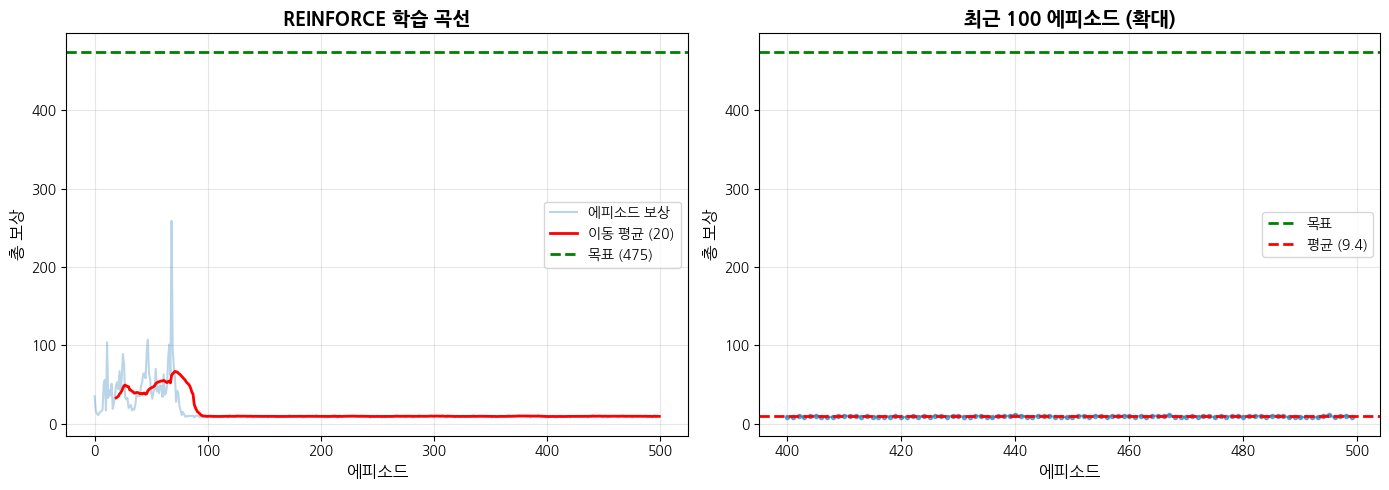


=== 학습 결과 통계 ===
총 에피소드: 500
평균 보상 (전체): 15.28
평균 보상 (최근 100): 9.45
최대 보상: 259
목표 달성 에피소드 (>475): 0


In [11]:
# 학습 곡선 그리기
plt.figure(figsize=(14, 5))

# 원본 데이터
plt.subplot(1, 2, 1)
plt.plot(all_rewards, alpha=0.3, label='에피소드 보상')

# 이동 평균
window = 20
if len(all_rewards) >= window:
    moving_avg = np.convolve(all_rewards, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(all_rewards)), moving_avg,
             label=f'이동 평균 ({window})', linewidth=2, color='red')

plt.axhline(y=475, color='green', linestyle='--', linewidth=2, label='목표 (475)')
plt.xlabel('에피소드', fontsize=12)
plt.ylabel('총 보상', fontsize=12)
plt.title('REINFORCE 학습 곡선', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 후반부 확대
plt.subplot(1, 2, 2)
last_100 = all_rewards[-100:]
plt.plot(range(len(all_rewards)-100, len(all_rewards)), last_100,
         marker='o', markersize=3, alpha=0.6)
plt.axhline(y=475, color='green', linestyle='--', linewidth=2, label='목표')
plt.axhline(y=np.mean(last_100), color='red', linestyle='--',
           linewidth=2, label=f'평균 ({np.mean(last_100):.1f})')
plt.xlabel('에피소드', fontsize=12)
plt.ylabel('총 보상', fontsize=12)
plt.title('최근 100 에피소드 (확대)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 통계 출력
print("\n=== 학습 결과 통계 ===")
print(f"총 에피소드: {len(all_rewards)}")
print(f"평균 보상 (전체): {np.mean(all_rewards):.2f}")
print(f"평균 보상 (최근 100): {np.mean(all_rewards[-100:]):.2f}")
print(f"최대 보상: {np.max(all_rewards):.0f}")
print(f"목표 달성 에피소드 (>475): {sum(1 for r in all_rewards if r > 475)}")

**설명**: 학습 곡선 분석
- **왼쪽 그래프**: 전체 학습 과정
  - 처음에는 낮은 점수
  - 점점 개선
  - 후반에는 높은 점수
- **오른쪽 그래프**: 최근 100 에피소드
  - 얼마나 안정적인지 확인
  - 목표(475) 달성 여부 확인

---

## 9단계: 학습된 정책 테스트

In [12]:
# 학습된 정책으로 10번 테스트
test_env = gym.make('CartPole-v1')
test_rewards = []

print("=== 학습된 정책 테스트 (10 에피소드) ===")
for i in range(10):
    _, _, rewards, _ = run_episode(test_env, policy_network)
    episode_reward = sum(rewards)
    test_rewards.append(episode_reward)
    print(f"테스트 {i+1}: {episode_reward:.0f} 스텝")

test_env.close()

print(f"\n평균: {np.mean(test_rewards):.2f} 스텝")
print(f"성공률 (>475): {sum(1 for r in test_rewards if r > 475)}/10")

if np.mean(test_rewards) > 475:
    print("\n축하합니다! CartPole을 마스터했습니다!")
else:
    print("\n아직 조금 부족합니다. 더 많은 에피소드로 학습해보세요.")

=== 학습된 정책 테스트 (10 에피소드) ===
테스트 1: 9 스텝
테스트 2: 11 스텝
테스트 3: 10 스텝
테스트 4: 11 스텝
테스트 5: 9 스텝
테스트 6: 10 스텝
테스트 7: 9 스텝
테스트 8: 9 스텝
테스트 9: 11 스텝
테스트 10: 10 스텝

평균: 9.90 스텝
성공률 (>475): 0/10

아직 조금 부족합니다. 더 많은 에피소드로 학습해보세요.


**설명**: 학습된 정책의 실제 성능을 평가합니다.
- 10번 테스트하여 평균 계산
- 475점 이상이면 성공!

---

## 10단계: 실험해보기

다양한 설정으로 실험해보세요!

실험 1: 학습률 비교 (시간이 걸립니다...)


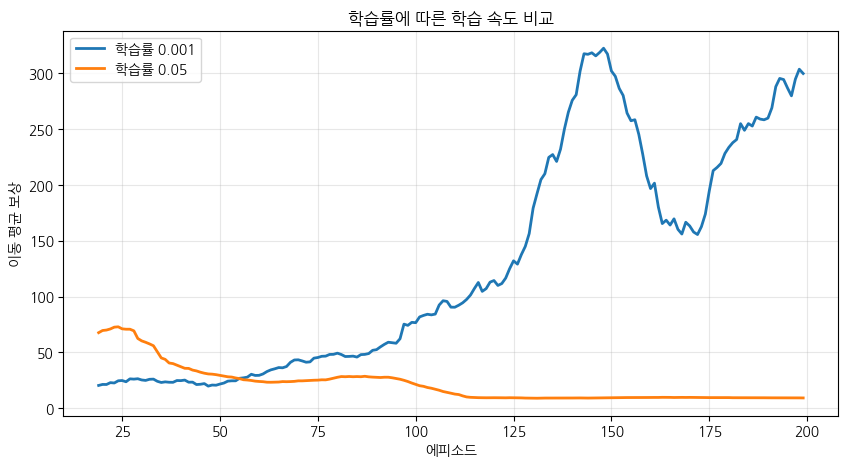

학습률 0.001: 평균 보상 = 239.46
학습률 0.05: 평균 보상 = 9.46


In [13]:
# 실험 함수
def experiment(learning_rate, gamma, n_episodes=300):
    """
    다양한 하이퍼파라미터로 실험
    """
    env = gym.make('CartPole-v1')
    policy_network = create_policy_network(state_dim, action_dim)
    optimizer = optim.Adam(policy_network.parameters(), lr=learning_rate)

    rewards = []

    for episode in range(n_episodes):
        states, actions, ep_rewards, log_probs = run_episode(env, policy_network)
        returns = compute_returns(ep_rewards, gamma)
        update_policy(policy_network, optimizer, log_probs, returns)
        rewards.append(sum(ep_rewards))

    env.close()
    return rewards

# 실험 1: 학습률 비교
print("실험 1: 학습률 비교 (시간이 걸립니다...)")
lr_small = experiment(learning_rate=0.001, gamma=0.99, n_episodes=200)
lr_large = experiment(learning_rate=0.05, gamma=0.99, n_episodes=200)

plt.figure(figsize=(10, 5))
window = 20

ma_small = np.convolve(lr_small, np.ones(window)/window, mode='valid')
ma_large = np.convolve(lr_large, np.ones(window)/window, mode='valid')

plt.plot(range(window-1, len(lr_small)), ma_small, label='학습률 0.001', linewidth=2)
plt.plot(range(window-1, len(lr_large)), ma_large, label='학습률 0.05', linewidth=2)
plt.xlabel('에피소드')
plt.ylabel('이동 평균 보상')
plt.title('학습률에 따른 학습 속도 비교')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"학습률 0.001: 평균 보상 = {np.mean(lr_small[-50:]):.2f}")
print(f"학습률 0.05: 평균 보상 = {np.mean(lr_large[-50:]):.2f}")

**설명**: 하이퍼파라미터 실험
- **학습률 작을 때**: 안정적이지만 느림
- **학습률 클 때**: 빠르지만 불안정할 수 있음

**여러분이 해볼 수 있는 실험**:
- `gamma` 값 변경 (0.9, 0.95, 0.99)
- `hidden_dim` 변경 (64, 128, 256)
- `n_episodes` 증가 (1000, 2000)

---

## 마무리

### 배운 내용
1. REINFORCE 알고리즘의 기본 원리
2. Policy Gradient의 작동 방식
3. CartPole 환경에서 실제 학습

### REINFORCE의 핵심
- 좋은 결과를 낸 행동의 확률을 높인다
- 나쁜 결과를 낸 행동의 확률을 낮춘다
- 확률적 정책으로 자연스러운 탐색

### 다음 단계
- PPO: 더 안정적이고 효율적인 알고리즘
- Actor-Critic: Variance를 줄이는 방법
- 더 복잡한 환경에 도전